# A simple CNN for the edge lover task



[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/deep-learning-ids/deep_learning_fs26/blob/main/notebooks/03a_cnn_edge_lover_keras_torch.ipynb)

**Storytime:** There is an art lover who only likes images with vertical stripes. The goal of this notebook is to use a CNN to classify if the art lover likes the image or not.

<img src="https://raw.githubusercontent.com/tensorchiefs/dl_course_2024/refs/heads/main/notebooks/art_lover.png" alt="Sample Image" width="150">


**Task:**
You train a very simple CNN with only 1 kernel to distinguish between images containing vertical and horizontal stripes. To check what pattern is recognized by the learned kernel you will visualize the weights of the kernel as an image. You will see that the CNN learns a useful kernel (either a vertical or horiziontal bar). You can experiment with the code to check the influence of the kernel size, the activation function and the pooling method on the result.  


**Dataset:** You work with an artficially generated dataset of greyscale images (50x50 pixel) with 10 vertical or horizontal bars. We want to classify them into whether the art lover, who only loves vertical strips, will like the image (y = 0) or not like the image (y = 1).  

The idea of the notebook is that you try to understand the provided code by running it, checking the output and playing with it by slightly changing the code and rerunning it.  

**Content:**
* defining and generating the dataset X_train and X_val
* visualize samples of the generated images
* use keras to train a CNN with only one kernel (5x5 pixel)
* visualize the weights of the learned kernel and interpret if it is useful
* repeat the last two steps to check if the learned kernel is always the same



## Imports


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#import os
#os.environ["KERAS_BACKEND"] = "torch" # Only needed if you intentionally want Keras to run on PyTorch instead of its default backend.

import keras

from keras.models import Sequential
from keras.layers import Dense, Convolution2D, MaxPooling2D, Flatten, Activation
from keras.utils import to_categorical

## Defining functions to generate images

Here we define the function to genere images with vertical and horizontal bars, the arguments of the functions are the size of the image and the number of bars you want to have. The bars are at random positions in the image with a random length. The image is black and white, meaning we have only two values for the pixels, 0 for black and 255 for white.

In [ ]:
def generate_image_with_bars(size, bar_nr, vertical=True):
    """
    Generate a synthetic grayscale image containing random bars (stripes).

    The function creates an image of shape (size, size, 1) initialized with zeros
    (black background). It then draws a specified number of random bars either
    vertically or horizontally by setting pixel values to 255 (white).

    Parameters
    ----------
    size : int
        Height and width of the square image (image shape will be size x size x 1).

    bar_nr : int
        Number of bars (stripes) to generate in the image.

    vertical : bool, optional (default=True)
        If True, vertical bars are generated.
        If False, horizontal bars are generated.

    Returns
    -------
    img : numpy.ndarray
        A NumPy array of shape (size, size, 1) with dtype uint8.
        Pixel values are:
            0   -> background (black)
            255 -> bars (white)

    Notes
    -----
    - Bar positions and lengths are randomly generated.
    - Bars start at a random coordinate and extend toward the image boundary.
    - Bars may overlap.
    """

    # Initialize empty (black) image
    img = np.zeros((size, size, 1), dtype="uint8")

    # Generate bars
    for i in range(bar_nr):
        # Random starting position
        x, y = np.random.randint(0, size, 2)

        # Random length extending from y to bottom boundary
        l = int(np.random.randint(y, size, 1)[0])

        # Draw vertical or horizontal bar
        if vertical:
            img[y:l, x, 0] = 255  # vertical bar
        else:
            img[x, y:l, 0] = 255  # horizontal bar

    return img


### Generate and visualize image examples



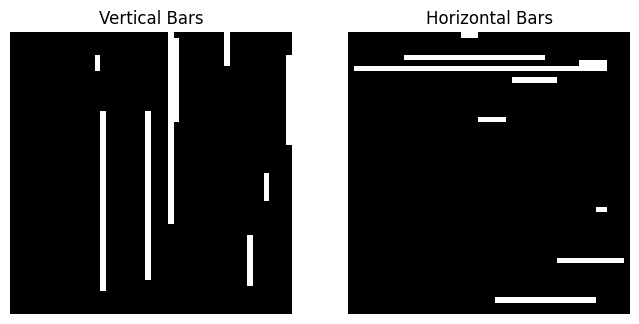

In [ ]:
# Visualize two example images generated with vertical and horizontal bars

# Create a new figure with a fixed size (8x8 inches)
plt.figure(figsize=(8, 8))

# ---- First subplot: Vertical bars ----
plt.subplot(1, 2, 1)  # Layout: 1 row, 2 columns, position 1
img = generate_image_with_bars(50, 10, vertical=True)

# Display the single channel (grayscale) image
# img[:,:,0] extracts the 2D image from shape (50, 50, 1)
plt.imshow(img[:, :, 0], cmap='gray')
plt.title("Vertical Bars")
plt.axis("off")  # Hide axis ticks for cleaner visualization


# ---- Second subplot: Horizontal bars ----
plt.subplot(1, 2, 2)  # Layout: 1 row, 2 columns, position 2
img = generate_image_with_bars(50, 10, vertical=False)

plt.imshow(img[:, :, 0], cmap='gray')
plt.title("Horizontal Bars")
plt.axis("off")


# Render the figure
plt.show()

## Create Training and Validation Datasets

We construct a training dataset X_train consisting of 1,000 synthetic images:

- 500 images containing vertical bars

- 500 images containing horizontal bars

- Each image is normalized by scaling pixel values from the range [0, 255] to [0, 1]. This is done by dividing all pixel values by 255. Normalization improves numerical stability and helps the CNN train more effectively.

In addition, we create a validation dataset X_val with the same properties:

- 1,000 images total

- 500 vertical-bar images

- 500 horizontal-bar images

- Pixel values normalized to the range [0, 1]

The validation dataset is used to evaluate the model’s performance during training and monitor its ability to generalize to unseen data.

In [ ]:
# ---------------------------------------------
# Dataset configuration
# ---------------------------------------------

pixel = 50  # Height and width of the square images (50x50 pixels)

num_images_train = 1000  # Number of training images (must be divisible by 2)
num_images_val = 1000    # Number of validation images (must be divisible by 2)


# ---------------------------------------------
# Generate training dataset
# ---------------------------------------------

# Initialize empty array for training data
# Shape: (number of images, height, width, channels)
X_train = np.zeros((num_images_train, pixel, pixel, 1))

# First half: images with vertical bars
for i in range(0, num_images_train // 2):
    X_train[i] = generate_image_with_bars(pixel, 10, vertical=True)

# Second half: images with horizontal bars
for i in range(num_images_train // 2, num_images_train):
    X_train[i] = generate_image_with_bars(pixel, 10, vertical=False)


# ---------------------------------------------
# Generate validation dataset
# ---------------------------------------------

# Initialize empty array for validation data
X_val = np.zeros((num_images_val, pixel, pixel, 1))

# First half: images with vertical bars
for i in range(0, num_images_val // 2):
    X_val[i] = generate_image_with_bars(pixel, 10, vertical=True)

# Second half: images with horizontal bars
for i in range(num_images_val // 2, num_images_val):
    X_val[i] = generate_image_with_bars(pixel, 10, vertical=False)

In [ ]:
# ---------------------------------------------
# Normalize image data
# ---------------------------------------------

# Scale pixel values from the range [0, 255] to [0, 1]
# This improves numerical stability and helps the CNN train more efficiently
X_train = X_train / 255
X_val   = X_val   / 255


# ---------------------------------------------
# Verify dataset shapes
# ---------------------------------------------

# Print the shape of the training and validation datasets
# Expected shape: (num_images, height, width, channels)
print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)

Training data shape: (1000, 50, 50, 1)
Validation data shape: (1000, 50, 50, 1)


## Create Labels for the Classification Task

Next, we define the labels for our artificial “art lover” classification task:

- Label 0 → The art lover likes the image (images with vertical bars)

- Label 1 → The art lover does not like the image (images with horizontal bars)

Since our neural network will have two output neurons, we apply one-hot encoding to the labels. This converts each class label into a binary vector:

- Class 0 → [1, 0]

- Class 1 → [0, 1]

One-hot encoding is commonly used in multi-class (including binary) classification tasks when using a softmax output layer and categorical cross-entropy loss.

In [ ]:
# ---------------------------------------------
# Create class labels
# ---------------------------------------------

# Define class labels:
# 0 → vertical bars (liked)
# 1 → horizontal bars (not liked)
y = np.array([[0], [1]])

# Repeat labels so that:
# - First half of the dataset corresponds to class 0
# - Second half corresponds to class 1
Y_train = np.repeat(y, num_images_train // 2)
Y_val   = np.repeat(y, num_images_val   // 2)


# ---------------------------------------------
# One-hot encode labels
# ---------------------------------------------

# Convert scalar labels into one-hot encoded vectors
# Class 0 → [1, 0]
# Class 1 → [0, 1]
Y_train = to_categorical(Y_train, 2)
Y_val   = to_categorical(Y_val, 2)

## Defining the CNN

We now define a simple convolutional neural network (CNN) for this binary classification task:

* The network uses a single convolutional filter (kernel) of size 5×5.
* The convolution output is passed through a linear activation (i.e., no non-linearity is applied at this stage).
* A max-pooling step then takes the maximum value over the entire activation map, reducing it to a single strong response. This value is used to decide whether the image is more likely to contain the preferred pattern.
* Finally, an output layer with softmax produces the class probabilities, i.e., the probability that the art lover likes (vertical bars) or does not like (horizontal bars) the image.

For training, we use the categorical cross-entropy loss function and optimize the model using mini-batches of 64 images per parameter update.



In [ ]:
# ---------------------------------------------
# Build the CNN model
# ---------------------------------------------

# Initialize a sequential model
model = Sequential()

# Convolutional layer:
# - 1 filter
# - Kernel size: 5x5
# - 'same' padding keeps the spatial dimensions unchanged
# - Input shape: (height, width, channels)
model.add(Convolution2D(1, (5, 5),
                        padding='same',
                        input_shape=(pixel, pixel, 1)))

# Linear activation (no non-linearity applied)
model.add(Activation('linear'))


# Global max pooling:
# The pooling window covers the entire activation map (pixel x pixel),
# effectively taking the maximum value across the full feature map.
model.add(MaxPooling2D(pool_size=(pixel, pixel)))

# Flatten the pooled output into a 1D vector
model.add(Flatten())

# Fully connected output layer with 2 neurons
# (one for each class)
model.add(Dense(2))

# Softmax activation to convert logits (unnormalized output values) into class probabilities
model.add(Activation('softmax'))


# ---------------------------------------------
# Compile the model
# ---------------------------------------------

# - Loss: categorical_crossentropy (for one-hot encoded labels)
# - Optimizer: Adam (adaptive gradient-based optimization)
# - Metric: accuracy (percentage of correctly classified images)
# NOTE: The model is trained to minimize categorical_crossentropy.
# The metric 'accuracy' is just reported during training
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ---------------------------------------------
# Display model architecture summary
# ---------------------------------------------

# Print a summary of the CNN architecture.
# This includes:
# - Each layer in the network
# - Output shape of every layer
# - Number of trainable parameters (weights + biases)
# - Total number of parameters in the model

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 50, 1)      │            26 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 50, 50, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1, 1, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30 (120.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ---------------------------------------------
# Train the CNN model
# ---------------------------------------------

# %%time measures the total execution time of the training cell (Jupyter/Colab magic command)
# This allows us to see how long the full training process takes.

%%time

history = model.fit(
    X_train, Y_train,                  # Training data and labels
    validation_data=(X_val, Y_val),    # Validation data for performance monitoring
    batch_size=64,                     # Number of images per gradient update
    epochs=100,                        # Number of full passes through the training dataset
    verbose=1                          # Print training progress for each epoch
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.5000 - loss: 0.9114 - val_accuracy: 0.5000 - val_loss: 0.8485
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 0.8249 - val_accuracy: 0.5000 - val_loss: 0.7721
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 0.7535 - val_accuracy: 0.5000 - val_loss: 0.7108
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 0.6963 - val_accuracy: 0.5000 - val_loss: 0.6592
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 0.6465 - val_accuracy: 0.5000 - val_loss: 0.6160
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5000 - loss: 0.6047 - val_accuracy: 0.5000 - val_loss: 0.5792
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 0.5693 - val_accuracy: 0.5000 - val_loss: 0.5481
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 0.5397 - val_accuracy: 0.5000 

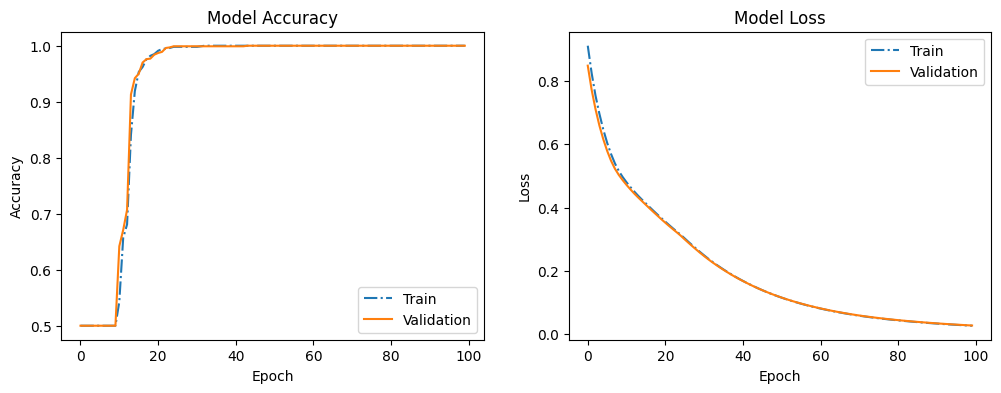

In [ ]:
# ---------------------------------------------
# Plot training history (accuracy and loss)
# ---------------------------------------------

# Create a figure with two subplots side by side
plt.figure(figsize=(12, 4))

# ----- Accuracy plot -----
plt.subplot(1, 2, 1)

# Training accuracy (dashed line)
plt.plot(history.history['accuracy'], linestyle='-.')

# Validation accuracy (solid line)
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')


# ----- Loss plot -----
plt.subplot(1, 2, 2)

# Training loss (dashed line)
plt.plot(history.history['loss'], linestyle='-.')

# Validation loss (solid line)
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

# 🔧 **YOUR TASK:**

## Visualize the learned kernel and experiment with the model

The CNN reaches perfect performance on this synthetic task because the two classes differ by a very clear geometric pattern: vertical vs horizontal bars.

To better understand what the network has learned, we can inspect:

- The learned 5×5 convolution kernel (the only filter in the conv layer)

- The activation map after the convolution (i.e., the “filtered image”)

- The single value after global max pooling (since the pooling window covers the whole activation map)

- :The model’s predicted probabilities for the selected validation image

Use the sliders to browse through images from X_val and see how the activation and prediction change.


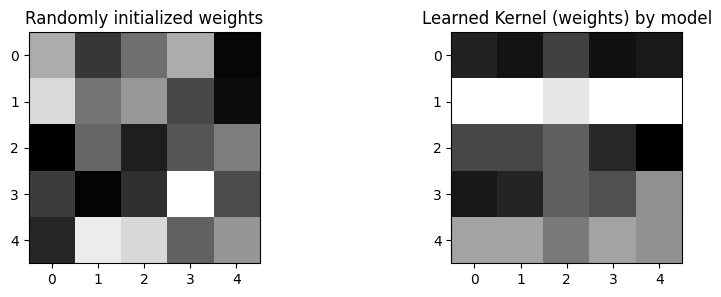

In [ ]:
# @title Random Kernel and Kernel learned based on the data { display-mode: "form" }
## This cell visualizes the learned convolution kernel and demonstrates
## how a single image is processed through convolution, max pooling,
## and the final prediction. Just move the sliders to explore.

import scipy.signal
from skimage.measure import block_reduce  # Used to simulate max pooling
import ipywidgets as widgets


# -----------------------------------------------------------
# Visualize a random kernel vs. the learned kernel
# -----------------------------------------------------------

plt.figure(figsize=(10, 3))

# Random 5x5 kernel (for comparison)
plt.subplot(1, 2, 1)
plt.imshow(np.random.rand(25).reshape(5, 5), "gray")
plt.title('Randomly initialized weights')

# Learned 5x5 convolution kernel from the trained model
plt.subplot(1, 2, 2)

# model.get_weights()[0] → convolution weights
# Shape: (5, 5, 1, 1) → remove singleton dimensions
conv_filter = np.squeeze(model.get_weights()[0], axis=2)

plt.imshow(conv_filter[:, :, 0], "gray")
plt.title('Learned Kernel (weights) by model')
plt.show()


# -----------------------------------------------------------
# Utility function: scale convolution output for visualization
# -----------------------------------------------------------

def scale_convolution_map(conv_map, min_val=-3, max_val=3):
    """
    Clips and rescales convolution outputs into [0, 1]
    so they can be displayed properly as grayscale images.
    """
    clipped_conv_map = np.clip(conv_map, min_val, max_val)
    scaled_conv_map = (clipped_conv_map - min_val) / (max_val - min_val)
    return scaled_conv_map


# -----------------------------------------------------------
# Core visualization function
# -----------------------------------------------------------

def plot_conv(img, category):
    """
    Shows the full processing pipeline for a single image:

    1. Original image
    2. Convolved image (using learned kernel + bias)
    3. Global max pooling result
    4. Model prediction and corresponding loss component
    5. Visualization of cross-entropy loss curve
    """

    # Perform 2D convolution using the learned kernel
    convolved_image = scipy.signal.convolve2d(
        img.squeeze(),
        conv_filter.squeeze(),
        mode='same'
    )

    # Add learned bias term
    convolved_with_bias = convolved_image + model.get_weights()[1]

    # Scale for visualization
    scaled_conv_image = scale_convolution_map(convolved_with_bias)

    # Simulate global max pooling (50x50 block → single value)
    max_pooled_image = block_reduce(
        convolved_with_bias,
        block_size=(50, 50),
        func=np.max
    )

    scaled_max_pooled_image = scale_convolution_map(max_pooled_image)

    # -------------------------------------------------------
    # Plot everything
    # -------------------------------------------------------

    plt.figure(figsize=(20, 4))

    # Original image
    plt.subplot(1, 6, 1)
    plt.imshow(img, "gray", vmin=0, vmax=1)
    plt.title('Original Image')

    # Convolved image
    plt.subplot(1, 6, 2)
    plt.imshow(scaled_conv_image, "gray", vmin=0, vmax=1)
    plt.title('Convolved Image')

    # Max pooled result (single value)
    plt.subplot(1, 6, 3)
    plt.imshow(scaled_max_pooled_image, "gray", vmin=0, vmax=1)
    plt.title(f'Max Pooled = {max_pooled_image[0][0]:.2f}')
    plt.xticks([])
    plt.yticks([])

    # -------------------------------------------------------
    # Prediction and loss
    # -------------------------------------------------------

    plt.subplot(1, 6, 4)
    plt.axis('off')

    # Predict class probabilities
    pred = model.predict(img.reshape(1, 50, 50, 1), verbose=0)

    # Compute relevant loss component (-log likelihood)
    if category == "vertical":
        loss_component = -np.log(pred[0][0])
    else:
        loss_component = -np.log(pred[0][1])

    text_info = f"""
    P(y=vertical | x):   {pred[0][0]:.4f}
    P(y=horizontal | x): {pred[0][1]:.4f}

    loss component: {loss_component:.4f}
    """

    plt.text(0, 0.5, text_info, ha='left', va='center')

    # -------------------------------------------------------
    # Cross-entropy loss curve visualization
    # -------------------------------------------------------

    plt.subplot(1, 6, 5)

    x_values = np.linspace(0.001, 1.1, 500)
    plt.plot(x_values, -np.log(x_values), label='-log(P(y|x))')

    plt.ylim(-0.5, 6)
    plt.xlim(-0.1, 1.1)
    plt.xlabel('P(y|x)')

    # Mark actual prediction probability on the curve
    if category == "vertical":
        plt.plot(pred[0][0], -np.log(pred[0][0]), 'bo', label='loss component')
    else:
        plt.plot(pred[0][1], -np.log(pred[0][1]), 'ro', label='loss component')

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------
# Interactive inspection function
# -----------------------------------------------------------

def inspect_preds(idx, category='vertical'):
    """
    Selects an image from the validation set and visualizes:
    - Convolution result
    - Max pooling
    - Prediction probabilities
    - Loss contribution
    """
    plot_conv(X_val[idx, :, :, 0], category)

In [ ]:
# -----------------------------------------------------------
# Interactive slider for inspecting validation images
# -----------------------------------------------------------

# Create a slider to browse through validation images
# Range:
# 0 → (num_images_val//2 - 1)
# This corresponds to the first half of X_val,
# which contains images with vertical bars.

horizontal_slider = widgets.IntSlider(
    min=0,
    max=num_images_val // 2 - 1,
    step=1,
    value=0,
    description='vertical'
)

# Connect the slider to the inspection function.
# The category is fixed to 'vertical', meaning:
# - The selected image is assumed to belong to the vertical class
# - The loss component will be computed for the vertical label
widgets.interact(
    inspect_preds,
    idx=horizontal_slider,
    category=widgets.fixed('vertical')
)

interactive(children=(IntSlider(value=0, description='vertical', max=499), Output()), _dom_classes=('widget-in…

<function __main__.inspect_preds(idx, category='vertical')>

In [ ]:
# -----------------------------------------------------------
# Interactive slider for horizontal validation images
# -----------------------------------------------------------

# Create a slider to browse through the second half
# of the validation dataset.
# Range:
# (num_images_val // 2) → (num_images_val - 1)
# This corresponds to images with horizontal bars.

vertical_slider = widgets.IntSlider(
    min=num_images_val // 2,
    max=num_images_val - 1,
    step=1,
    value=num_images_val // 2,   # Start at first horizontal example
    description='horizontal'
)

# Connect the slider to the inspection function.
# The category is fixed to 'horizontal', meaning:
# - The selected image is assumed to belong to the horizontal class
# - The loss component will be computed for the horizontal label
widgets.interact(
    inspect_preds,
    idx=vertical_slider,
    category=widgets.fixed('horizontal')
)

interactive(children=(IntSlider(value=500, description='horizontal', max=999, min=500), Output()), _dom_classe…

<function __main__.inspect_preds(idx, category='vertical')>

## Discussion
1. Given the learned filter, can you explain the difference between the convolved images of vertical vs. horizontal patterns?

2. What does the max-pooling do?
Max-pooling over the entire kernel area:
If a vertical-bar detector fires strongly at any location,
that’s enough to conclude:

“Yes — this image contains vertical bars.”

We don’t need location information.
We only need existence of the pattern.

### Additional Exercise

You can now experiment with the architecture and observe how design choices affect performance. In particular, try changing:

- Kernel size (e.g., 3×3, 7×7)

- Number of kernels / filters (e.g., 1, 2, 8, 16)

- Activation function (e.g., relu instead of linear)

- Pooling method (e.g., AveragePooling2D instead of MaxPooling2D)

Before running an experiment, make a prediction about what you expect to happen (e.g., faster learning, higher accuracy, overfitting, or worse generalization) and then compare it to the actual result.

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.4820 - loss: 0.6972 - val_accuracy: 0.5310 - val_loss: 0.6628
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6510 - loss: 0.6363 - val_accuracy: 0.7710 - val_loss: 0.6066
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8120 - loss: 0.5826 - val_accuracy: 0.9010 - val_loss: 0.5565
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9320 - loss: 0.5345 - val_accuracy: 0.9630 - val_loss: 0.5102
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9880 - loss: 0.4897 - val_accuracy: 0.9960 - val_loss: 0.4669
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9970 - loss: 0.4474 - val_accuracy: 1.0000 - val_loss: 0.4261
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.4081 - val_accuracy: 1.0000 - val_loss: 0.3887
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.3722 - val_accuracy: 1.0000 - val_los

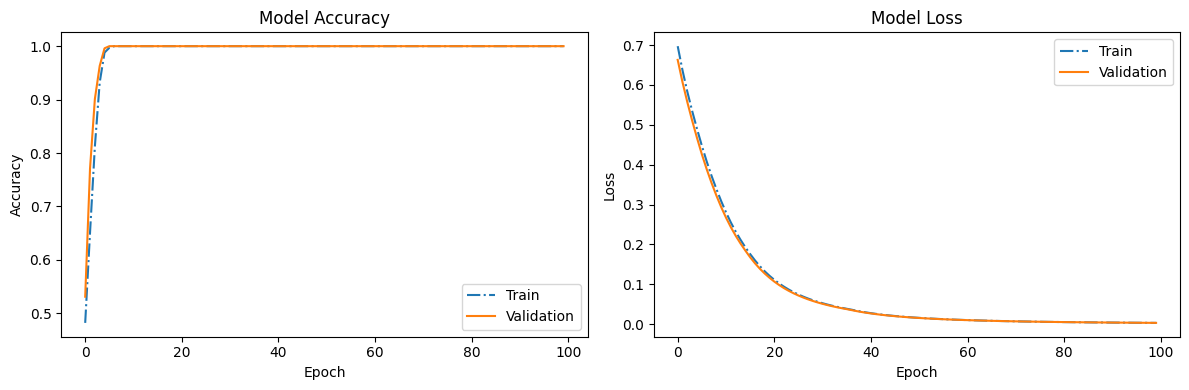

In [ ]:
# -----------------------------------------------------------
# Experiment: more filters + ReLU activation
# -----------------------------------------------------------

# In this variant, we increase the number of convolution filters from 1 to 2
# and replace the linear activation with ReLU. This gives the model more
# capacity and introduces non-linearity, which can help learning.

model = Sequential()

# Convolutional layer:
# - 2 filters (instead of 1)
# - Kernel size: 5x5
# - 'same' padding keeps the activation map size unchanged
model.add(Convolution2D(2, (5, 5),
                        padding='same',
                        input_shape=(pixel, pixel, 1)))

# ReLU activation:
# - sets negative values to 0
# - often helps optimization and learning useful features
model.add(Activation('relu'))


# Global max pooling:
# Pool over the entire activation map, leaving one value per filter.
# With 2 filters, this produces 2 pooled values (one per filter).
model.add(MaxPooling2D(pool_size=(pixel, pixel)))

# Flatten pooled outputs into a 1D vector
model.add(Flatten())

# Output layer with 2 neurons (vertical vs horizontal)
model.add(Dense(2))

# Softmax converts logits into probabilities
model.add(Activation('softmax'))


# -----------------------------------------------------------
# Compile model
# -----------------------------------------------------------

# - categorical_crossentropy: for one-hot encoded labels
# - adam: standard adaptive optimizer
# - accuracy: fraction of correctly classified images
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


# -----------------------------------------------------------
# Train model
# -----------------------------------------------------------

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    batch_size=64,
    epochs=100,
    verbose=1
)


# -----------------------------------------------------------
# Plot training curves
# -----------------------------------------------------------

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], linestyle='-.')
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], linestyle='-.')
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()

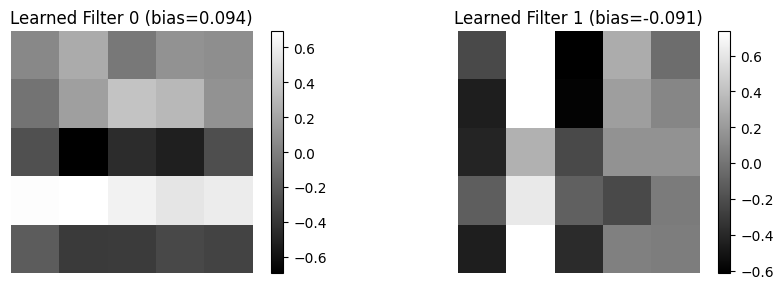

In [ ]:
# -----------------------------------------------------------
# Plot learned kernels of the current (2-filter) model
# -----------------------------------------------------------

# Extract convolution layer weights and biases
# get_weights() returns:
# [conv_weights, conv_bias, dense_weights, dense_bias]
conv_weights_new, conv_bias_new, _, _ = model.get_weights()

# Conv2D weight shape: (5, 5, 1, 2)
# → two 5x5 kernels (one per filter)
kernel_0 = conv_weights_new[:, :, 0, 0]
kernel_1 = conv_weights_new[:, :, 0, 1]

plt.figure(figsize=(10, 3))

# Filter 0
plt.subplot(1, 2, 1)
plt.imshow(kernel_0, cmap="gray")
plt.title(f"Learned Filter 0 (bias={conv_bias_new[0]:.3f})")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

# Filter 1
plt.subplot(1, 2, 2)
plt.imshow(kernel_1, cmap="gray")
plt.title(f"Learned Filter 1 (bias={conv_bias_new[1]:.3f})")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()